# ANN ile Aynı Yapıya Yakın QNN Modeli

Bu notebook, klasik ANN modeliyle adil karşılaştırma yapılabilmesi için QNN modelini aynı deneysel akışa göre düzenler:

- EfficientNet-B0 ile 1280 boyutlu derin öznitelik çıkarımı
- StandardScaler
- PCA(256)
- PCA sonrası StandardScaler
- ANN modeliyle aynı Linear + BatchNorm + GELU + Dropout tabanlı klasik gövde
- Son bölümde 4 qubitli QNN bloğu
- 5 katlı Stratified K-Fold hiperparametre araması
- Macro-F1'e göre en iyi QNN model seçimi
- Testte sınıf bazlı doğru/yanlış tahmin tablosu

Not: Yapı klasik ANN ile birebir aynı değildir; çünkü QNN modelinde zorunlu olarak kuantum katman bulunur. Ancak ön işleme, özellik çıkarımı ve klasik gövde aynı tutularak karşılaştırma mümkün olduğunca adil hale getirilmiştir.

---


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.7 MB/s eta 0:00:00
Özellik çıkarım cihazı: cpu
QNN eğitim cihazı: cpu
Sınıf eşlemesi: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

Kayıtlı train/test ayrımı kontrol ediliyor.
Kayıtlı train/test ayrımı yüklendi ve dosya yolları geçerli.

Sınıf bazlı toplam görüntü sayısı:


,Sınıf,Görüntü sayısı
0,glioma_tumor,926
1,meningioma_tumor,937
2,no_tumor,500
3,pituitary_tumor,901



Eğitim görüntü sayısı: 2609
Test görüntü sayısı   : 655
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 120MB/s] 



Feature extractor: EfficientNet-B0
Ham özellik boyutu: 1280

Kayıtlı EfficientNet-B0 özellikleri yükleniyor:
/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp/efficientnet_b0_features_seed42_img224.npz

Ham özellik şekilleri:
X_train_raw: (2609, 1280)
X_test_raw : (655, 1280)

PCA sonrası özellik şekilleri:
X_train_features: (2609, 256)
X_test_features : (655, 256)
PCA açıklanan varyans: 0.8574

5 KATLI STRATIFIED K-FOLD HİPERPARAMETRE ARAMA BAŞLIYOR

--- Konfigürasyon: qnn_256_128_64_do030_lr1e-3 ---
Fold 1/5 | Best Val Macro-F1: 0.8929 | Best Epoch: 44
Fold 2/5 | Best Val Macro-F1: 0.8697 | Best Epoch: 24
Fold 3/5 | Best Val Macro-F1: 0.8798 | Best Epoch: 39
Fold 4/5 | Best Val Macro-F1: 0.8783 | Best Epoch: 35
Fold 5/5 | Best Val Macro-F1: 0.8389 | Best Epoch: 45

--- Konfigürasyon: qnn_256_128_64_do035_lr7e-4 ---
Fold 1/5 | Best Val Macro-F1: 0.6927 | Best Epoch: 45
Fold 2/5 | Best Val Macro-F1: 0.8160 | Best Epoch: 42
Fold 3/5 | Best Val Macro-F1: 0.40

...

,Dosya yolu,Dosya adı,Gerçek sınıf,Tahmin edilen sınıf,Sonuç,Tahmin güveni,Gerçek sınıf olasılığı,Tahmin edilen sınıf olasılığı
0,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (272).jpg,glioma_tumor,glioma_tumor,Doğru,0.9323,0.9323,0.9323
1,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m1(57).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.9002,0.0823,0.9002
2,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (374).jpg,glioma_tumor,glioma_tumor,Doğru,0.9277,0.9277,0.9277
3,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,T105.jpg,no_tumor,no_tumor,Doğru,0.8411,0.8411,0.8411
4,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (321).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.4613,0.1473,0.4613
...,...,...,...,...,...,...,...,...
650,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(27).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.6059,0.1589,0.6059
651,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m3 (155).jpg,meningioma_tumor,meningioma_tumor,Doğru,0.9147,0.9147,0.9147
652,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m (186).jpg,meningioma_tumor,meningioma_tumor,Doğru,0.9144,0.9144,0.9144
653,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (492).jpg,glioma_tumor,glioma_tumor,Doğru,0.9277,0.9277,0.9277



Görüntü bazlı detaylı test sonuçları kaydedildi:
/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_qnn_same_ann_structure_fair/test_goruntu_bazli_sonuclar.csv

SADECE YANLIŞ TAHMİN EDİLEN TEST GÖRÜNTÜLERİ


,Dosya yolu,Dosya adı,Gerçek sınıf,Tahmin edilen sınıf,Sonuç,Tahmin güveni,Gerçek sınıf olasılığı,Tahmin edilen sınıf olasılığı
1,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m1(57).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.9002,0.0823,0.9002
4,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (321).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.4613,0.1473,0.4613
8,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (159).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.3710,0.3602,0.3710
18,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(193).jpg,no_tumor,glioma_tumor,Yanlış,0.8540,0.0253,0.8540
19,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,gg (368).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.4781,0.1511,0.4781
...,...,...,...,...,...,...,...,...
591,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,m3 (41).jpg,meningioma_tumor,glioma_tumor,Yanlış,0.8843,0.0937,0.8843
598,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(64).jpg,no_tumor,meningioma_tumor,Yanlış,0.5245,0.0428,0.5245
600,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(133).jpg,no_tumor,meningioma_tumor,Yanlış,0.4194,0.0669,0.4194
611,/content/drive/MyDrive/Beyin_MR_Kuantum_Makale...,image(1).jpg,glioma_tumor,meningioma_tumor,Yanlış,0.9099,0.0654,0.9099



CLASSIFICATION REPORT
                  precision    recall  f1-score   support

    glioma_tumor     0.9353    0.8548    0.8933       186
meningioma_tumor     0.8350    0.9149    0.8731       188
        no_tumor     0.9438    0.8400    0.8889       100
 pituitary_tumor     0.9368    0.9834    0.9596       181

        accuracy                         0.9053       655
       macro avg     0.9127    0.8983    0.9037       655
    weighted avg     0.9082    0.9053    0.9051       655



<Figure size 800x600 with 0 Axes>

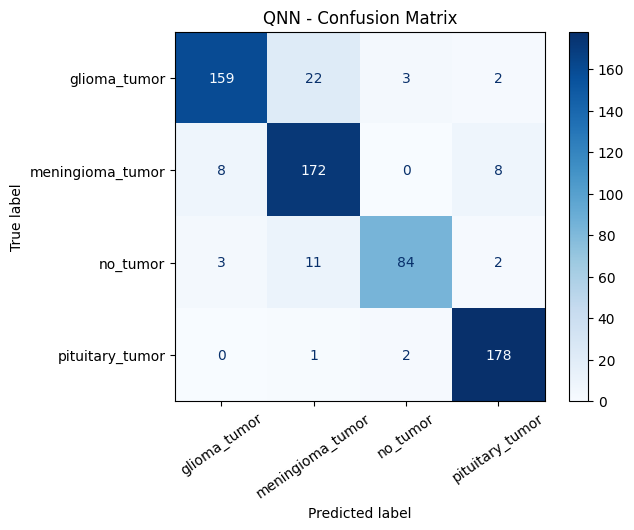

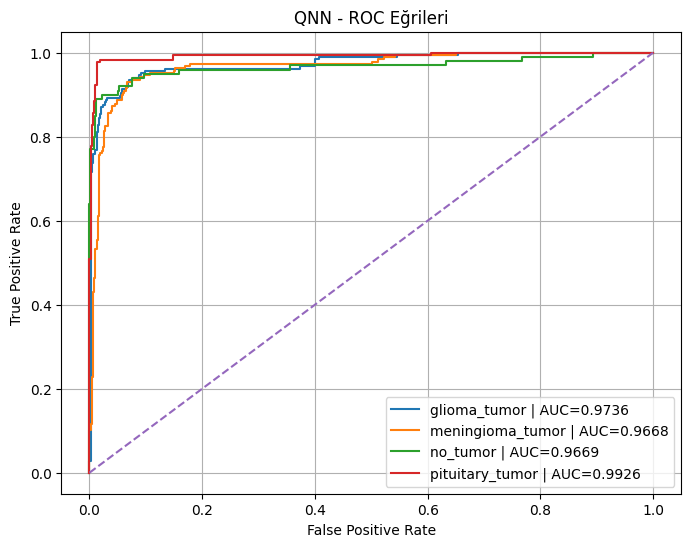


MAKALE / SLAYT İÇİN KISA ÖZET

QNN modelinde, MR görüntülerinden önceden eğitilmiş EfficientNet-B0 modeli
ile 1280 boyutlu derin öznitelikler çıkarılmıştır. Bu öznitelikler klasik ANN modeliyle
aynı biçimde önce standartlaştırılmış, ardından PCA ile 256 boyuta
indirgenmiş ve PCA sonrası tekrar standartlaştırılmıştır. Sınıflandırma aşamasında,
ANN modelindeki Linear, BatchNorm, GELU ve Dropout tabanlı MLP gövdesi korunmuş;
son bölümde 4 qubitli AngleEmbedding ve StronglyEntanglingLayers tabanlı
QNN bloğu kullanılmıştır. Böylece QNN modeli, klasik ANN ile aynı ön işleme ve çok
yakın sınıflandırıcı iskeleti üzerinde hibrit klasik-kuantum yapı olarak tasarlanmıştır.
Hiperparametreler 5 katlı Stratified K-Fold doğrulama ile Macro-F1 ölçütüne göre seçilmiştir.

Test kümesindeki toplam 655 görüntünün 593 tanesi doğru,
62 tanesi yanlış sınıflandırılmıştır. Modelin genel test doğruluğu
0.9053, Macro-F1 değeri 0.9037 olarak elde edilmiştir.



In [1]:
# ============================================================
# GÜÇLENDİRİLMİŞ QNN KARŞILAŞTIRMA MODELİ
# DÜZELTME: Data/Training + Data/Testing klasör yapısı otomatik algılanır
# QNN modeli, klasik ANN ile adil karşılaştırma yapılabilmesi için
# aynı güçlü deneysel akışa göre yeniden düzenlenmiştir:
# EfficientNet-B0 özellik çıkarımı + StandardScaler + PCA(256)
# + PCA sonrası StandardScaler + 5 katlı StratifiedKFold ile
# hiperparametre seçimi + ANN ile aynı ön işleme ve MLP gövdesi üzerine QNN sınıflandırıcı bloğu kullanılır.
#
# Not: Bu model hibrit klasik-kuantum yapıdadır; klasik ANN gövdesi korunmuş, son bölümde QNN bloğu kullanılmıştır.
# Test verilerinde sınıf bazlı doğru / yanlış tahmin tablosu dahil.
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# ============================================================
# 1) KURULUMLAR
# ============================================================
!pip -q install --upgrade pip
!pip -q install torchvision scikit-learn pandas tqdm matplotlib joblib openpyxl pennylane

# ============================================================
# 2) IMPORTLAR
# ============================================================
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

import torchvision.transforms as T
import torchvision.models as models

import matplotlib.pyplot as plt
import joblib
import pennylane as qml

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)
from sklearn.utils.class_weight import compute_class_weight

# ============================================================
# 3) GENEL AYARLAR
# ============================================================
SEED = 42


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)

# EfficientNet-B0 özellik çıkarımı GPU'da yapılabilir.
FEATURE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# PennyLane tabanlı QNN katmanı CPU'da daha kararlı çalışır.
# Bu nedenle sınıflandırıcı eğitimi CPU üzerinde yürütülür.
DEVICE = torch.device("cpu")

print("Özellik çıkarım cihazı:", FEATURE_DEVICE)
print("QNN eğitim cihazı:", DEVICE)

# Burayı kendi veri klasörüne göre kontrol et
DATA_ROOT = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data"

CLASS_NAMES = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor"
]

CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: cls for cls, i in CLASS_TO_IDX.items()}
N_CLASSES = len(CLASS_NAMES)

CLASS_DIRS = {cls: os.path.join(DATA_ROOT, cls) for cls in CLASS_NAMES}

IMG_SIZE = 224
TEST_SIZE = 0.20

FEATURE_BATCH_SIZE = 64
PCA_COMPONENTS = 256

# QNN bölümü için sabit ayarlar.
# Dört sınıflı problemle uyumlu ve hesaplama maliyeti düşük olması için 4 qubit kullanılır.
N_QUBITS = 4
N_QUANTUM_LAYERS = 2

# ANN modeliyle aynı deneysel akış korunarak QNN hiperparametre araması yapılır.
N_FOLDS = 5
SEARCH_MAX_EPOCHS = 45
SEARCH_PATIENCE = 7
FINAL_MIN_EPOCHS = 8

FORCE_REEXTRACT_IMAGE_FEATURES = False

CACHE_DIR = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_qnn_same_ann_structure_fair"
os.makedirs(CACHE_DIR, exist_ok=True)

# Adil karşılaştırma için son oluşturulan güçlü ANN modeliyle aynı
# train/test ayrımı ve aynı EfficientNet-B0 özellik cache'i varsa onu kullanır.
REFERENCE_CNN_CACHE_DIR = "/content/drive/MyDrive/Beyin_MR_Kuantum_Makale/cache_classical_cnn_strong_mlp"
REFERENCE_FEATURE_CACHE_PATH = os.path.join(
    REFERENCE_CNN_CACHE_DIR,
    f"efficientnet_b0_features_seed{SEED}_img{IMG_SIZE}.npz"
)
REFERENCE_TRAIN_SPLIT_PATH = os.path.join(REFERENCE_CNN_CACHE_DIR, "train_split.csv")
REFERENCE_TEST_SPLIT_PATH = os.path.join(REFERENCE_CNN_CACHE_DIR, "test_split.csv")

LOCAL_FEATURE_CACHE_PATH = os.path.join(CACHE_DIR, f"efficientnet_b0_features_seed{SEED}_img{IMG_SIZE}.npz")
LOCAL_TRAIN_SPLIT_PATH = os.path.join(CACHE_DIR, "train_split.csv")
LOCAL_TEST_SPLIT_PATH = os.path.join(CACHE_DIR, "test_split.csv")

FEATURE_CACHE_PATH = REFERENCE_FEATURE_CACHE_PATH if os.path.exists(REFERENCE_FEATURE_CACHE_PATH) else LOCAL_FEATURE_CACHE_PATH
TRAIN_SPLIT_PATH = REFERENCE_TRAIN_SPLIT_PATH if os.path.exists(REFERENCE_TRAIN_SPLIT_PATH) else LOCAL_TRAIN_SPLIT_PATH
TEST_SPLIT_PATH = REFERENCE_TEST_SPLIT_PATH if os.path.exists(REFERENCE_TEST_SPLIT_PATH) else LOCAL_TEST_SPLIT_PATH

MODEL_SAVE_PATH = os.path.join(CACHE_DIR, "strong_qnn_same_ann_structure_model.pt")
SCALER_PCA_SAVE_PATH = os.path.join(CACHE_DIR, "qnn_scaler_pca_post_scaler.joblib")
SEARCH_RESULTS_PATH = os.path.join(CACHE_DIR, "qnn_hyperparametre_arama_sonuclari.csv")
DETAIL_TEST_RESULTS_PATH = os.path.join(CACHE_DIR, "test_goruntu_bazli_sonuclar.csv")
CLASS_SUMMARY_PATH = os.path.join(CACHE_DIR, "sinif_bazli_dogru_yanlis_sonuclar.csv")
CONFUSION_DETAIL_PATH = os.path.join(CACHE_DIR, "siniflar_arasi_karisiklik_tablosu.csv")

print("Sınıf eşlemesi:", CLASS_TO_IDX)

# ============================================================
# 4) VERİLERİ LİSTELEME VE 80/20 BÖLME
# ============================================================
# Bu bölüm hata almamak için esnek hale getirildi.
# Aşağıdaki iki veri klasörü düzenini de destekler:
# 1) Data/glioma_tumor, Data/meningioma_tumor, ...
# 2) Data/Training/glioma_tumor + Data/Testing/glioma_tumor, ...
# İkinci düzende Training ve Testing klasörleri önce birleştirilir,
# sonra tüm modellerle adil karşılaştırma için yine sınıf bazlı 80/20 bölme yapılır.

IMAGE_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")


def list_images(folder, warn=False):
    files = []

    if not os.path.isdir(folder):
        if warn:
            print("UYARI: Klasör bulunamadı:", folder)
        return files

    for root, _, names in os.walk(folder):
        for name in names:
            if name.lower().endswith(IMAGE_EXTS):
                files.append(os.path.join(root, name))

    return sorted(files)


def collect_class_files(data_root, class_names):
    """Veri klasörünü otomatik algılar ve her sınıf için dosyaları döndürür."""
    # 1) Düz klasör yapısı: Data/class_name
    flat_dirs = {cls: os.path.join(data_root, cls) for cls in class_names}
    flat_files = {cls: list_images(flat_dirs[cls]) for cls in class_names}

    if all(len(flat_files[cls]) > 0 for cls in class_names):
        print("\nVeri düzeni algılandı: Data/sınıf_adi biçimi")
        return flat_files, "flat"

    # 2) Training + Testing klasör yapısı: Data/Training/class_name ve Data/Testing/class_name
    train_root = os.path.join(data_root, "Training")
    test_root = os.path.join(data_root, "Testing")

    split_files = {}
    for cls in class_names:
        files_train = list_images(os.path.join(train_root, cls))
        files_test = list_images(os.path.join(test_root, cls))
        # Aynı dosya iki yerde görünürse tekrarları kaldır.
        split_files[cls] = sorted(list(dict.fromkeys(files_train + files_test)))

    if all(len(split_files[cls]) > 0 for cls in class_names):
        print("\nVeri düzeni algılandı: Data/Training + Data/Testing biçimi")
        print("Not: Training ve Testing klasörleri birleştirildi; sonra sınıf bazlı 80/20 bölme yapıldı.")
        return split_files, "training_testing_combined"

    # 3) Hata mesajını anlaşılır yapmak için bulunan klasörleri göster.
    print("\nVeri klasörü bulunamadı veya sınıf klasörleri boş görünüyor.")
    print("Kontrol edilen ana klasör:", data_root)
    if os.path.isdir(data_root):
        print("Data klasörü içeriği:", sorted(os.listdir(data_root))[:30])
    else:
        print("Data klasörü mevcut değil:", data_root)

    print("\nBeklenen seçeneklerden biri şöyle olmalı:")
    print("1) /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data/glioma_tumor")
    print("2) /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data/Training/glioma_tumor")
    print("   /content/drive/MyDrive/Beyin_MR_Kuantum_Makale/Data/Testing/glioma_tumor")

    raise FileNotFoundError(
        "Sınıf görüntüleri bulunamadı. DATA_ROOT yolunu veya klasör yapısını kontrol edin."
    )


def build_classwise_split_from_files(class_files, class_names, test_size=0.2, seed=42):
    """Her sınıf dosyalarını ayrı ayrı 80/20 böler."""
    train_items = []
    test_items = []
    class_counts = {}

    for cls in class_names:
        files = sorted(class_files[cls])
        class_counts[cls] = len(files)

        if len(files) == 0:
            raise ValueError(f"Bu sınıf için görüntü bulunamadı: {cls}")

        y = CLASS_TO_IDX[cls]

        tr, te = train_test_split(
            files,
            test_size=test_size,
            random_state=seed,
            shuffle=True
        )

        train_items.extend([(p, y, cls) for p in tr])
        test_items.extend([(p, y, cls) for p in te])

    rng = np.random.default_rng(seed)
    rng.shuffle(train_items)
    rng.shuffle(test_items)

    return train_items, test_items, class_counts


def save_split_csv(items, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    df = pd.DataFrame(items, columns=["path", "label", "class_name"])
    df.to_csv(path, index=False)


def load_split_csv(path):
    df = pd.read_csv(path)
    return [
        (str(row["path"]), int(row["label"]), str(row["class_name"]))
        for _, row in df.iterrows()
    ]


def split_paths_are_valid(items):
    if len(items) == 0:
        return False
    return all(os.path.exists(item[0]) for item in items)


# Önce aynı CNN/MLP modelinden gelen kayıtlı split varsa onu kullanır.
# Fakat kayıtlı split eski/yanlış klasör yoluna bakıyorsa otomatik yeniden oluşturur.
use_saved_split = os.path.exists(TRAIN_SPLIT_PATH) and os.path.exists(TEST_SPLIT_PATH)

if use_saved_split:
    print("\nKayıtlı train/test ayrımı kontrol ediliyor.")
    train_items = load_split_csv(TRAIN_SPLIT_PATH)
    test_items = load_split_csv(TEST_SPLIT_PATH)

    if split_paths_are_valid(train_items) and split_paths_are_valid(test_items):
        print("Kayıtlı train/test ayrımı yüklendi ve dosya yolları geçerli.")
        class_counts = {
            cls: sum(1 for _, _, cls_name in train_items + test_items if cls_name == cls)
            for cls in CLASS_NAMES
        }
    else:
        print("Kayıtlı split var ancak dosya yolları bu Colab oturumunda geçersiz görünüyor.")
        print("Veri klasörü otomatik algılanıp split yeniden oluşturulacak.")
        use_saved_split = False

if not use_saved_split:
    class_files, detected_layout = collect_class_files(DATA_ROOT, CLASS_NAMES)
    train_items, test_items, class_counts = build_classwise_split_from_files(
        class_files,
        CLASS_NAMES,
        test_size=TEST_SIZE,
        seed=SEED
    )

    save_split_csv(train_items, TRAIN_SPLIT_PATH)
    save_split_csv(test_items, TEST_SPLIT_PATH)

print("\nSınıf bazlı toplam görüntü sayısı:")
display(pd.DataFrame([
    {"Sınıf": cls, "Görüntü sayısı": class_counts[cls]}
    for cls in CLASS_NAMES
]))

print(f"\nEğitim görüntü sayısı: {len(train_items)}")
print(f"Test görüntü sayısı   : {len(test_items)}")

# ============================================================
# 5) EFFICIENTNET-B0 İLE DERİN ÖZNİTELİK ÇIKARIMI
# ============================================================
weights = models.EfficientNet_B0_Weights.DEFAULT
feature_transform = weights.transforms()


class ImagePathDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, y, cls_name = self.items[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, y


def build_efficientnet_b0_feature_extractor():
    model = models.efficientnet_b0(weights=weights)
    model.classifier = nn.Identity()  # 1280 boyutlu özellik vektörü üretir.
    model = model.to(FEATURE_DEVICE)
    model.eval()

    for p in model.parameters():
        p.requires_grad = False

    return model


feature_extractor = build_efficientnet_b0_feature_extractor()
print("\nFeature extractor: EfficientNet-B0")
print("Ham özellik boyutu: 1280")


@torch.no_grad()
def extract_features(items, split_name):
    dataset = ImagePathDataset(items, feature_transform)
    loader = DataLoader(
        dataset,
        batch_size=FEATURE_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=(FEATURE_DEVICE.type == "cuda")
    )

    features = []
    labels_out = []

    for x, y in tqdm(loader, desc=f"{split_name} özellikleri çıkarılıyor"):
        x = x.to(FEATURE_DEVICE, non_blocking=True)
        f = feature_extractor(x)
        features.append(f.detach().cpu().numpy().astype(np.float32))
        labels_out.append(np.asarray(y, dtype=np.int64))

    X = np.concatenate(features, axis=0)
    y = np.concatenate(labels_out, axis=0)
    return X, y


if os.path.exists(FEATURE_CACHE_PATH) and not FORCE_REEXTRACT_IMAGE_FEATURES:
    print("\nKayıtlı EfficientNet-B0 özellikleri yükleniyor:")
    print(FEATURE_CACHE_PATH)
    data = np.load(FEATURE_CACHE_PATH)
    X_train_raw = data["X_train_raw"]
    y_train = data["y_train"]
    X_test_raw = data["X_test_raw"]
    y_test = data["y_test"]
else:
    X_train_raw, y_train = extract_features(train_items, "Eğitim")
    X_test_raw, y_test = extract_features(test_items, "Test")

    np.savez_compressed(
        FEATURE_CACHE_PATH,
        X_train_raw=X_train_raw,
        y_train=y_train,
        X_test_raw=X_test_raw,
        y_test=y_test
    )
    print("\nÖzellikler kaydedildi:")
    print(FEATURE_CACHE_PATH)

print("\nHam özellik şekilleri:")
print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)

# ============================================================
# 6) STANDARD SCALER + PCA + PCA SONRASI SCALER
# ============================================================
# Güçlü SVM modelindeki mantığa benzer biçimde, PCA'dan önce ve sonra ölçekleme yapılır.
raw_scaler = StandardScaler()
X_train_scaled = raw_scaler.fit_transform(X_train_raw).astype(np.float32)
X_test_scaled = raw_scaler.transform(X_test_raw).astype(np.float32)

pca_dim = min(PCA_COMPONENTS, X_train_scaled.shape[0] - 1, X_train_scaled.shape[1])

pca = PCA(n_components=pca_dim, random_state=SEED, svd_solver="randomized")
X_train_pca = pca.fit_transform(X_train_scaled).astype(np.float32)
X_test_pca = pca.transform(X_test_scaled).astype(np.float32)

post_pca_scaler = StandardScaler()
X_train_features = post_pca_scaler.fit_transform(X_train_pca).astype(np.float32)
X_test_features = post_pca_scaler.transform(X_test_pca).astype(np.float32)

explained_var = float(np.sum(pca.explained_variance_ratio_))

print("\nPCA sonrası özellik şekilleri:")
print("X_train_features:", X_train_features.shape)
print("X_test_features :", X_test_features.shape)
print(f"PCA açıklanan varyans: {explained_var:.4f}")

joblib.dump(
    {
        "raw_scaler": raw_scaler,
        "pca": pca,
        "post_pca_scaler": post_pca_scaler,
        "class_names": CLASS_NAMES,
        "pca_explained_variance": explained_var
    },
    SCALER_PCA_SAVE_PATH
)

# ============================================================
# 7) GÜÇLENDİRİLMİŞ QNN SINIFLANDIRICI
# ============================================================
class StrongQNNClassifier(nn.Module):
    """PCA ile indirgenmiş EfficientNet özellikleri üzerinde çalışan QNN sınıflandırıcı.

    Bu yapı klasik ANN modeliyle aynı deneysel akışı kullanır:
    EfficientNet-B0 -> StandardScaler -> PCA(256) -> PCA sonrası StandardScaler.
    ANN'deki Linear + BatchNorm + GELU + Dropout gövdesi korunur.
    Fark olarak son bölümde klasik çıkış katmanı yerine AngleEmbedding ve
    StronglyEntanglingLayers tabanlı kuantum QNN bloğu kullanılır.
    """

    def __init__(
        self,
        input_dim,
        num_classes,
        hidden_dims=(256, 128, 64),
        dropout=0.35,
        n_qubits=N_QUBITS,
        n_quantum_layers=N_QUANTUM_LAYERS
    ):
        super().__init__()

        self.n_qubits = n_qubits
        self.n_quantum_layers = n_quantum_layers

        layers = []
        prev_dim = input_dim

        # Klasik ANN ile aynı MLP gövdesi
        for layer_idx, hidden_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.GELU(),
                nn.Dropout(dropout * (0.85 ** layer_idx))
            ])
            prev_dim = hidden_dim

        self.classical_body = nn.Sequential(*layers)

        # Klasik özellik vektörünü qubit açılarına indirger.
        self.to_quantum_angles = nn.Sequential(
            nn.Linear(prev_dim, n_qubits),
            nn.BatchNorm1d(n_qubits),
            nn.Tanh()
        )

        quantum_device = qml.device("default.qubit", wires=n_qubits)

        @qml.qnode(quantum_device, interface="torch", diff_method="backprop")
        def quantum_circuit(inputs, weights):
            # inputs şekli: [batch, n_qubits]
            # Tanh sonrası [-1, 1] aralığındaki değerler pi ile açıya dönüştürülür.
            qml.AngleEmbedding(inputs * np.pi, wires=range(n_qubits), rotation="Y")
            qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
            return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

        weight_shapes = {
            "weights": (n_quantum_layers, n_qubits, 3)
        }

        self.q_layer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        # Kuantum ölçüm çıktıları dört sınıflı klasik logit çıktısına dönüştürülür.
        self.output_layer = nn.Linear(n_qubits, num_classes)

    def forward(self, x):
        z = self.classical_body(x)
        angles = self.to_quantum_angles(z)
        q_out = self.q_layer(angles)

        # PennyLane çıktısı bazı sürümlerde [n_qubits, batch] dönebilir.
        # Gerekirse [batch, n_qubits] biçimine çevrilir.
        if q_out.dim() == 2 and q_out.shape[0] == self.n_qubits and q_out.shape[1] == x.shape[0]:
            q_out = q_out.T

        logits = self.output_layer(q_out.float())
        return logits


def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda")
    )


def get_class_weights(y):
    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(N_CLASSES),
        y=y
    )
    return torch.tensor(weights, dtype=torch.float32).to(DEVICE)


def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    n = 0

    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

    return total_loss / max(n, 1)


@torch.no_grad()
def predict_proba(model, X, batch_size=512):
    model.eval()
    dummy_y = np.zeros(len(X), dtype=np.int64)
    loader = make_loader(X, dummy_y, batch_size=batch_size, shuffle=False)
    probs_all = []

    for xb, _ in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1)
        probs_all.append(probs.detach().cpu().numpy())

    return np.concatenate(probs_all, axis=0)


def safe_macro_auc(y_true, y_proba):
    try:
        return roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro")
    except Exception:
        return np.nan


def evaluate_from_proba(y_true, y_proba, model_name):
    y_pred = np.argmax(y_proba, axis=1)
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "macro_auc": safe_macro_auc(y_true, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba
    }


def print_result(result):
    print("\n===================================================")
    print(result["model"])
    print("===================================================")
    print(f"Accuracy    : {result['accuracy']:.4f}")
    print(f"Macro-F1    : {result['macro_f1']:.4f}")
    print(f"Weighted-F1 : {result['weighted_f1']:.4f}")
    print(f"Macro-AUC   : {result['macro_auc']:.4f}")

# ============================================================
# 8) ANN İLE AYNI YAPIYA YAKIN QNN HİPERPARAMETRE ARAMA
# ============================================================
SEARCH_CONFIGS = [
    {
        "name": "qnn_256_128_64_do030_lr1e-3",
        "hidden_dims": (256, 128, 64),
        "dropout": 0.30,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "label_smoothing": 0.03,
        "batch_size": 64
    },
    {
        "name": "qnn_256_128_64_do035_lr7e-4",
        "hidden_dims": (256, 128, 64),
        "dropout": 0.35,
        "lr": 7e-4,
        "weight_decay": 1e-4,
        "label_smoothing": 0.03,
        "batch_size": 64
    },
    {
        "name": "qnn_384_192_96_do035_lr7e-4",
        "hidden_dims": (384, 192, 96),
        "dropout": 0.35,
        "lr": 7e-4,
        "weight_decay": 2e-4,
        "label_smoothing": 0.04,
        "batch_size": 64
    },
    {
        "name": "qnn_512_256_128_do040_lr5e-4",
        "hidden_dims": (512, 256, 128),
        "dropout": 0.40,
        "lr": 5e-4,
        "weight_decay": 2e-4,
        "label_smoothing": 0.04,
        "batch_size": 64
    },
    {
        "name": "qnn_256_128_do025_lr1e-3",
        "hidden_dims": (256, 128),
        "dropout": 0.25,
        "lr": 1e-3,
        "weight_decay": 5e-5,
        "label_smoothing": 0.02,
        "batch_size": 64
    }
]

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)


def train_with_early_stopping(X_tr, y_tr, X_val, y_val, config, seed, verbose=False):
    seed_everything(seed)

    train_loader = make_loader(X_tr, y_tr, batch_size=config["batch_size"], shuffle=True)

    model = StrongQNNClassifier(
        input_dim=X_tr.shape[1],
        num_classes=N_CLASSES,
        hidden_dims=config["hidden_dims"],
        dropout=config["dropout"]
    ).to(DEVICE)

    class_weights = get_class_weights(y_tr)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=config["label_smoothing"]
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    best_val_macro_f1 = -1.0
    best_epoch = 1
    best_state = None
    wait = 0

    for epoch in range(1, SEARCH_MAX_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_proba = predict_proba(model, X_val)
        val_result = evaluate_from_proba(y_val, val_proba, "Validation")
        val_macro_f1 = val_result["macro_f1"]
        scheduler.step(val_macro_f1)

        if verbose:
            print(
                f"Epoch {epoch:03d} | Loss: {train_loss:.4f} | "
                f"Val Acc: {val_result['accuracy']:.4f} | Val Macro-F1: {val_macro_f1:.4f}"
            )

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= SEARCH_PATIENCE:
            break

    return {
        "best_val_macro_f1": best_val_macro_f1,
        "best_epoch": best_epoch,
        "best_state": best_state
    }


print("\n===================================================")
print("5 KATLI STRATIFIED K-FOLD HİPERPARAMETRE ARAMA BAŞLIYOR")
print("===================================================")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
search_rows = []

for cfg_idx, config in enumerate(SEARCH_CONFIGS):
    fold_scores = []
    fold_epochs = []

    print(f"\n--- Konfigürasyon: {config['name']} ---")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_features, y_train), start=1):
        X_tr = X_train_features[tr_idx]
        y_tr = y_train[tr_idx]
        X_val = X_train_features[val_idx]
        y_val = y_train[val_idx]

        out = train_with_early_stopping(
            X_tr,
            y_tr,
            X_val,
            y_val,
            config,
            seed=SEED + cfg_idx * 100 + fold,
            verbose=False
        )

        fold_scores.append(out["best_val_macro_f1"])
        fold_epochs.append(out["best_epoch"])

        print(
            f"Fold {fold}/{N_FOLDS} | "
            f"Best Val Macro-F1: {out['best_val_macro_f1']:.4f} | "
            f"Best Epoch: {out['best_epoch']}"
        )

    row = {
        "config_name": config["name"],
        "hidden_dims": str(config["hidden_dims"]),
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config["weight_decay"],
        "label_smoothing": config["label_smoothing"],
        "batch_size": config["batch_size"],
        "mean_macro_f1": float(np.mean(fold_scores)),
        "std_macro_f1": float(np.std(fold_scores)),
        "mean_best_epoch": float(np.mean(fold_epochs)),
        "fold_scores": str([round(x, 4) for x in fold_scores]),
        "fold_epochs": str(fold_epochs)
    }
    search_rows.append(row)

search_df = pd.DataFrame(search_rows).sort_values(
    ["mean_macro_f1", "std_macro_f1"],
    ascending=[False, True]
).reset_index(drop=True)

print("\n===================================================")
print("HİPERPARAMETRE ARAMA SONUÇLARI")
print("===================================================")
display(search_df.round(4))
search_df.to_csv(SEARCH_RESULTS_PATH, index=False)
print("\nArama sonuçları kaydedildi:")
print(SEARCH_RESULTS_PATH)

best_config_name = search_df.loc[0, "config_name"]
best_config = next(cfg for cfg in SEARCH_CONFIGS if cfg["name"] == best_config_name)
final_epochs = int(round(search_df.loc[0, "mean_best_epoch"]))
final_epochs = max(final_epochs, FINAL_MIN_EPOCHS)

print("\nSeçilen en iyi QNN konfigürasyonu:", best_config)
print("Final eğitim epoch sayısı:", final_epochs)

# ============================================================
# 9) TÜM EĞİTİM VERİSİYLE FİNAL QNN MODELİNİ EĞİTME
# ============================================================
seed_everything(SEED)

final_loader = make_loader(
    X_train_features,
    y_train,
    batch_size=best_config["batch_size"],
    shuffle=True
)

final_model = StrongQNNClassifier(
    input_dim=X_train_features.shape[1],
    num_classes=N_CLASSES,
    hidden_dims=best_config["hidden_dims"],
    dropout=best_config["dropout"]
).to(DEVICE)

final_class_weights = get_class_weights(y_train)
final_criterion = nn.CrossEntropyLoss(
    weight=final_class_weights,
    label_smoothing=best_config["label_smoothing"]
)

final_optimizer = torch.optim.AdamW(
    final_model.parameters(),
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"]
)

print("\n===================================================")
print("FİNAL QNN EĞİTİMİ BAŞLIYOR")
print("===================================================")

final_history = []

for epoch in range(1, final_epochs + 1):
    train_loss = train_one_epoch(
        final_model,
        final_loader,
        final_optimizer,
        final_criterion
    )
    final_history.append({"Epoch": epoch, "Train Loss": train_loss})
    print(f"Final Epoch {epoch:03d} | Loss: {train_loss:.4f}")

final_history_df = pd.DataFrame(final_history)

# ============================================================
# 10) MODELİ KAYDETME
# ============================================================
torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "input_dim": X_train_features.shape[1],
        "num_classes": N_CLASSES,
        "class_names": CLASS_NAMES,
        "pca_dim": X_train_features.shape[1],
        "pca_explained_variance": explained_var,
        "n_qubits": N_QUBITS,
        "n_quantum_layers": N_QUANTUM_LAYERS,
        "best_config": best_config,
        "final_epochs": final_epochs,
        "search_results": search_df.to_dict(orient="records")
    },
    MODEL_SAVE_PATH
)

print("\nFinal model kaydedildi:")
print(MODEL_SAVE_PATH)

# ============================================================
# 11) TEST DEĞERLENDİRMESİ
# ============================================================
test_proba = predict_proba(final_model, X_test_features)

qnn_result = evaluate_from_proba(
    y_test,
    test_proba,
    "QNN: EfficientNet-B0 + PCA(256) + post-scaler + ANN gövdesi + Quantum Layer"
)

print_result(qnn_result)

y_pred = qnn_result["y_pred"]
y_proba = qnn_result["y_proba"]

test_total = len(y_test)
correct_total = int(np.sum(y_pred == y_test))
wrong_total = int(np.sum(y_pred != y_test))

general_summary_df = pd.DataFrame([{
    "Model": qnn_result["model"],
    "Test toplam": test_total,
    "Doğru tahmin": correct_total,
    "Yanlış tahmin": wrong_total,
    "Accuracy": qnn_result["accuracy"],
    "Macro-F1": qnn_result["macro_f1"],
    "Weighted-F1": qnn_result["weighted_f1"],
    "Macro-AUC": qnn_result["macro_auc"],
    "Seçilen config": best_config_name,
    "Final epoch": final_epochs
}])

print("\n===================================================")
print("GENEL TEST SONUÇ TABLOSU")
print("===================================================")
display(general_summary_df.round(4))

# ============================================================
# 12) SINIF BAZLI DOĞRU / YANLIŞ TAHMİN TABLOSU
# ============================================================
cm = confusion_matrix(y_test, y_pred, labels=np.arange(N_CLASSES))

class_rows = []

for i, cls in enumerate(CLASS_NAMES):
    test_count = int(cm[i, :].sum())
    correct_count = int(cm[i, i])
    wrong_count = int(test_count - correct_count)

    class_rows.append({
        "Gerçek sınıf": cls,
        "Test toplam": test_count,
        "Doğru tahmin": correct_count,
        "Yanlış tahmin": wrong_count,
        "Sınıf doğruluğu (%)": round(100 * correct_count / max(test_count, 1), 2),
        "Yanlış sınıflandırma (%)": round(100 * wrong_count / max(test_count, 1), 2)
    })

class_summary_df = pd.DataFrame(class_rows)

total_row = pd.DataFrame([{
    "Gerçek sınıf": "Toplam",
    "Test toplam": int(cm.sum()),
    "Doğru tahmin": int(np.trace(cm)),
    "Yanlış tahmin": int(cm.sum() - np.trace(cm)),
    "Sınıf doğruluğu (%)": round(100 * np.trace(cm) / max(cm.sum(), 1), 2),
    "Yanlış sınıflandırma (%)": round(100 * (cm.sum() - np.trace(cm)) / max(cm.sum(), 1), 2)
}])

class_summary_df = pd.concat([class_summary_df, total_row], ignore_index=True)

print("\n===================================================")
print("SINIF BAZLI DOĞRU / YANLIŞ TAHMİN TABLOSU")
print("===================================================")
display(class_summary_df)

class_summary_df.to_csv(CLASS_SUMMARY_PATH, index=False)
print("\nSınıf bazlı sonuç tablosu kaydedildi:")
print(CLASS_SUMMARY_PATH)

# ============================================================
# 13) SINIFLAR ARASI KARIŞIKLIK TABLOSU
# ============================================================
confusion_detail_df = pd.DataFrame(
    cm,
    index=[f"Gerçek: {cls}" for cls in CLASS_NAMES],
    columns=[f"Tahmin: {cls}" for cls in CLASS_NAMES]
)

print("\n===================================================")
print("SINIFLAR ARASI KARIŞIKLIK TABLOSU")
print("Satırlar gerçek sınıfı, sütunlar tahmin edilen sınıfı gösterir.")
print("===================================================")
display(confusion_detail_df)

confusion_detail_df.to_csv(CONFUSION_DETAIL_PATH)
print("\nSınıflar arası karışıklık tablosu kaydedildi:")
print(CONFUSION_DETAIL_PATH)

# ============================================================
# 14) HER TEST GÖRÜNTÜSÜ İÇİN DETAYLI TAHMİN TABLOSU
# ============================================================
test_paths = [item[0] for item in test_items]

detail_rows = []

for idx in range(len(y_test)):
    true_label = int(y_test[idx])
    pred_label = int(y_pred[idx])

    true_class = IDX_TO_CLASS[true_label]
    pred_class = IDX_TO_CLASS[pred_label]

    max_prob = float(np.max(y_proba[idx]))
    true_prob = float(y_proba[idx, true_label])
    pred_prob = float(y_proba[idx, pred_label])

    detail_rows.append({
        "Dosya yolu": test_paths[idx],
        "Dosya adı": os.path.basename(test_paths[idx]),
        "Gerçek sınıf": true_class,
        "Tahmin edilen sınıf": pred_class,
        "Sonuç": "Doğru" if true_label == pred_label else "Yanlış",
        "Tahmin güveni": round(max_prob, 4),
        "Gerçek sınıf olasılığı": round(true_prob, 4),
        "Tahmin edilen sınıf olasılığı": round(pred_prob, 4)
    })

detail_df = pd.DataFrame(detail_rows)

print("\n===================================================")
print("GÖRÜNTÜ BAZLI DETAYLI TEST SONUÇLARI")
print("===================================================")
display(detail_df)

detail_df.to_csv(DETAIL_TEST_RESULTS_PATH, index=False)
print("\nGörüntü bazlı detaylı test sonuçları kaydedildi:")
print(DETAIL_TEST_RESULTS_PATH)

wrong_detail_df = detail_df[detail_df["Sonuç"] == "Yanlış"].copy()

print("\n===================================================")
print("SADECE YANLIŞ TAHMİN EDİLEN TEST GÖRÜNTÜLERİ")
print("===================================================")
display(wrong_detail_df)

# ============================================================
# 15) CLASSIFICATION REPORT
# ============================================================
print("\n===================================================")
print("CLASSIFICATION REPORT")
print("===================================================")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

# ============================================================
# 16) CONFUSION MATRIX GRAFİĞİ
# ============================================================
plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    xticks_rotation=35,
    values_format="d",
    cmap="Blues"
)

plt.title("QNN - Confusion Matrix")
plt.grid(False)
plt.show()

# ============================================================
# 17) ROC EĞRİLERİ
# ============================================================
y_test_bin = label_binarize(y_test, classes=np.arange(N_CLASSES))

plt.figure(figsize=(8, 6))

for i, cls in enumerate(CLASS_NAMES):
    try:
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_i = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{cls} | AUC={auc_i:.4f}")
    except Exception:
        pass

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("QNN - ROC Eğrileri")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 18) MAKALE / SLAYT İÇİN KISA ÖZET METİN
# ============================================================
print("\n===================================================")
print("MAKALE / SLAYT İÇİN KISA ÖZET")
print("===================================================")

print(f"""
QNN modelinde, MR görüntülerinden önceden eğitilmiş EfficientNet-B0 modeli
ile 1280 boyutlu derin öznitelikler çıkarılmıştır. Bu öznitelikler klasik ANN modeliyle
aynı biçimde önce standartlaştırılmış, ardından PCA ile {X_train_features.shape[1]} boyuta
indirgenmiş ve PCA sonrası tekrar standartlaştırılmıştır. Sınıflandırma aşamasında,
ANN modelindeki Linear, BatchNorm, GELU ve Dropout tabanlı MLP gövdesi korunmuş;
son bölümde {N_QUBITS} qubitli AngleEmbedding ve StronglyEntanglingLayers tabanlı
QNN bloğu kullanılmıştır. Böylece QNN modeli, klasik ANN ile aynı ön işleme ve çok
yakın sınıflandırıcı iskeleti üzerinde hibrit klasik-kuantum yapı olarak tasarlanmıştır.
Hiperparametreler {N_FOLDS} katlı Stratified K-Fold doğrulama ile Macro-F1 ölçütüne göre seçilmiştir.

Test kümesindeki toplam {test_total} görüntünün {correct_total} tanesi doğru,
{wrong_total} tanesi yanlış sınıflandırılmıştır. Modelin genel test doğruluğu
{qnn_result['accuracy']:.4f}, Macro-F1 değeri {qnn_result['macro_f1']:.4f} olarak elde edilmiştir.
""")
